# PF-5039: Análisis de Imágenes Médicas y Biológicas
## Semana 02 — Tarea Autónoma Calificada (1 a 1.5 Horas)
### Implementación Manual de HE y Caso de Estudio Biomédico con CLAHE

**Estudiante:** ____________________________________ **Carné:** __________________

---
### Instrucciones de Entrega:
- Complete los dos ejercicios programando las celdas marcadas con `TODO`.
- Debe subir su cuaderno resuelto en formato `.ipynb` antes de la fecha límite establecida.
- **Rigor:** En la Parte A no está permitido el uso de funciones de alto nivel de OpenCV (como `cv2.equalizeHist`). Debe construir el algoritmo desde cero utilizando únicamente álgebra vectorial de NumPy.

**Referencias:**
1. González, R. C., & Woods, R. E. (2018). *Digital Image Processing* (4th ed.). Pearson. Cap. 3.
2. Zuiderveld, K. (1994). Contrast Limited Adaptive Histogram Equalization. *Graphics Gems IV*, 474–485.

---
### Ejercicio 1 (50%): Implementación Manual de Ecualización de Histograma (HE) en NumPy

**Fundamento Teórico:**
La Ecualización de Histograma busca transformar la variable aleatoria de intensidad $r \in [0, L-1]$ mediante su Función de Distribución Acumulada (CDF):
$$s_k = T(r_k) = \text{round}\left( (L-1) \sum_{j=0}^{k} p(r_j) \right) = \text{round}\left( \frac{L-1}{M \cdot N} \sum_{j=0}^{k} h(r_j) \right)$$

**Instrucciones:**
1. Cargue la imagen histológica `histopatologia_ihc.png` en escala de grises.
2. Implemente la función `ecualizacion_manual_numpy(img)` **únicamente con NumPy** (sin OpenCV):
   - Calcule el histograma de conteo $h(r_k)$ para los 256 niveles.
   - Calcule la CDF acumulada discreta con `np.cumsum`.
   - Escale la CDF al rango $[0, 255]$, redondee y convierta a `uint8`.
   - Utilice la CDF resultante como una Look-Up Table de indexación sobre la matriz de la imagen: `img_eq = cdf_escalada[img]`.
3. Valide su implementación contra la función nativa `cv2.equalizeHist(img)` calculando el **PSNR** ($> 45\text{ dB}$) y el Error Cuadrático Medio (**MSE**).

Imagen cargada: (512, 512), dtype=uint8
Validación de Concordancia con OpenCV
Error Cuadrático Medio (MSE): 0.0000e+00
PSNR:                          inf dB


/Users/emilychacon/Desktop/2. Curso imágenes/analisis-imagenes/.venv/lib/python3.13/site-packages/skimage/metrics/simple_metrics.py:171: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


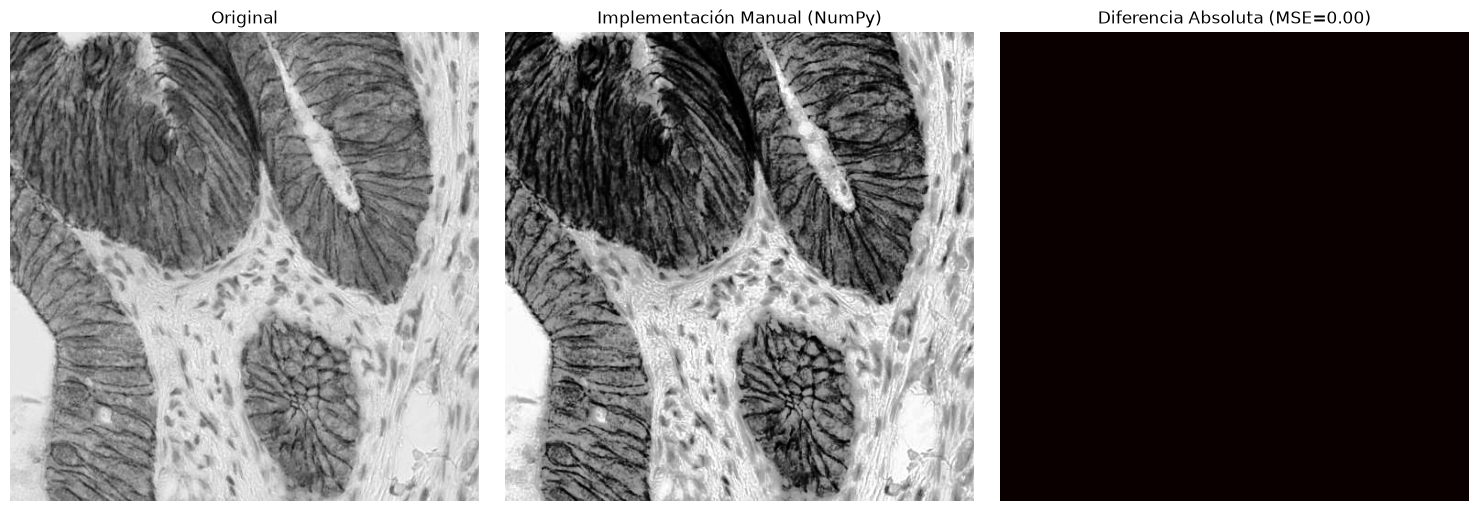

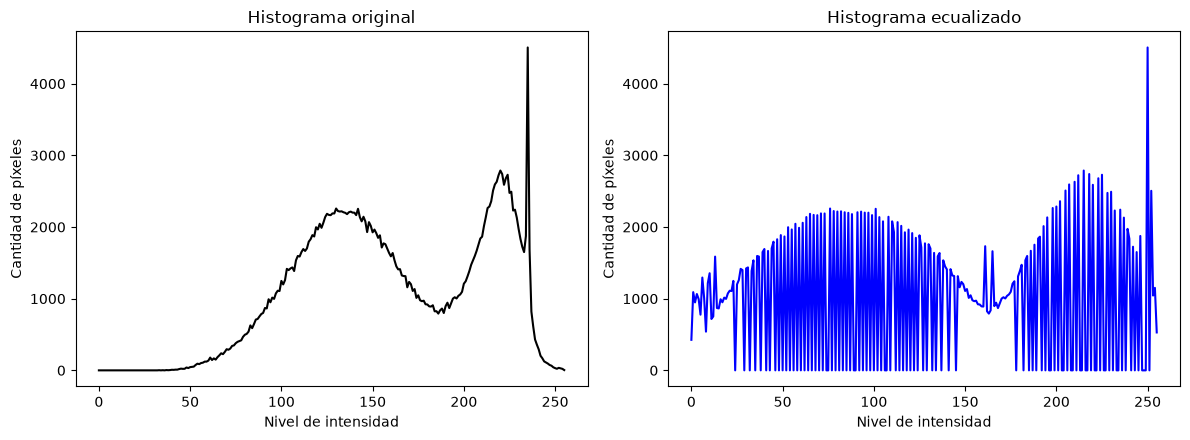

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse

# Función auxiliar de carga compatible con rutas con acentos en Windows
def leer_imagen(ruta, flags=cv2.IMREAD_GRAYSCALE):
    img = cv2.imread(ruta, flags)
    if img is None and os.path.exists(ruta):
        img = cv2.imdecode(np.fromfile(ruta, dtype=np.uint8), flags)
    return img

# 1. Cargar imagen de prueba
img_ihc = leer_imagen('/Users/emilychacon/Desktop/2. Curso imágenes/analisis-imagenes/tareas/tarea1/imagenes/histopatologia_ihc.png')
assert img_ihc is not None, "Error al cargar histopatologia_ihc.png"
print(f"Imagen cargada: {img_ihc.shape}, dtype={img_ihc.dtype}")

def ecualizacion_manual_numpy(img):
    """
    Implementación manual de Ecualización Global de Histograma (HE) con NumPy.
    Args:
        img (np.ndarray): Imagen en escala de grises (uint8).
    Returns:
        np.ndarray: Imagen ecualizada (uint8).
    """

    hist, _ = np.histogram(img.ravel(), bins=256, range=[0, 256])
    cdf = np.cumsum(hist)
    cdf_min = cdf[cdf > 0][0] if len(cdf[cdf > 0]) > 0 else 0
    total_pixels = img.size
    cdf_lut = np.round(((cdf - cdf_min) / (total_pixels - cdf_min)) * 255.0).astype(np.uint8)
    return cdf_lut[img]


# 2. Ejecutar implementación manual vs OpenCV
img_manual = ecualizacion_manual_numpy(img_ihc)
img_opencv = cv2.equalizeHist(img_ihc)

# 3. Validación cuantitativa
val_mse = mse(img_opencv, img_manual)
val_psnr = psnr(img_opencv, img_manual, data_range=255)

print(f"Validación de Concordancia con OpenCV")
print(f"Error Cuadrático Medio (MSE): {val_mse:.4e}")
print(f"PSNR:                          {val_psnr:.2f} dB")

# 4. Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_ihc, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(img_manual, cmap='gray'); axes[1].set_title('Implementación Manual (NumPy)'); axes[1].axis('off')
axes[2].imshow(np.abs(img_opencv.astype(int) - img_manual.astype(int)), cmap='hot')
axes[2].set_title(f'Diferencia Absoluta (MSE={val_mse:.2f})'); axes[2].axis('off')
plt.tight_layout()
plt.show()


# 5. Calcular el histograma de la imagen original y de la imagen ecualizada
hist_original, _ = np.histogram(img_ihc.ravel(), bins=256, range=[0, 256])
hist_ecualizado, _ = np.histogram(img_manual.ravel(), bins=256, range=[0, 256])

# 6. Graficar ambos histogramas
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(hist_original, color='black')
axes[0].set_title('Histograma original')
axes[0].set_xlabel('Nivel de intensidad')
axes[0].set_ylabel('Cantidad de píxeles')

axes[1].plot(hist_ecualizado, color='blue')
axes[1].set_title('Histograma ecualizado')
axes[1].set_xlabel('Nivel de intensidad')
axes[1].set_ylabel('Cantidad de píxeles')

plt.tight_layout()
plt.show()

### Conclusión del Ejercicio 1
Se implementó la ecualización de histograma manualmente con NumPy, calculando el
histograma, la CDF acumulada y una Look-Up Table para transformar cada píxel de la imagen.
Al comparar el resultado contra `cv2.equalizeHist`, se obtuvo un MSE de 0.0000 y un PSNR
infinito, lo que significa que la implementación coincide exactamente con la de OpenCV.
Esto confirma que el algoritmo quedó correctamente implementado, superando el umbral de
PSNR > 45 dB exigido. El panel de Diferencia Absoluta se muestra negro porque se calcula
como el valor absoluto de la resta píxel a píxel entre la imagen ecualizada con OpenCV y
la manual. Al no existir ninguna diferencia entre ambas (MSE = 0), esa resta da cero en
todos los píxeles, y el color negro en el mapa de colores representa el valor cero.

Por último, se graficaron los histogramas antes y después de la ecualización. El histograma
original muestra los píxeles concentrados en un rango angosto, entre 100 y 250, con muy
pocos valores cerca de los extremos (0 y 255), lo cual refleja el bajo contraste de la
imagen original. El histograma ecualizado, en cambio, muestra las intensidades distribuidas
a lo largo de todo el rango de 0 a 255, lo que confirma visualmente que el algoritmo logró
aprovechar mejor el rango dinámico disponible y aumentar el contraste de la imagen.

---
### Ejercicio 2 (50%): Análisis de Hiperparámetros de CLAHE y Evaluación de Calidad en Bioimágenes

**Contexto Biomédico:** En imágenes histológicas o radiológicas, seleccionar inadecuadamente los hiperparámetros de CLAHE puede generar dos problemas:
- **`clipLimit` muy alto:** Pierde la restricción de recorte y converge hacia AHE convencional, amplificando el ruido de fondo.
- **`tileGridSize` muy pequeño:** Genera bloques diminutos con discontinuidades o texturas artificiales.

**Instrucciones:**
1. Aplique CLAHE variando sistemáticamente el límite de recorte `clipLimit` $\in [1.0, 2.0, 4.0, 8.0]$ manteniendo `tileGridSize=(8, 8)`.
2. Calcule la **Entropía de Shannon ($H$)** y la **Desviación Estándar ($\\sigma$) del contraste** para cada configuración.
3. Grafique la evolución de la métrica en función del `clipLimit`.
4. Redacte su **Conclusión Crítica (mínimo 5 oraciones)** en la celda final.

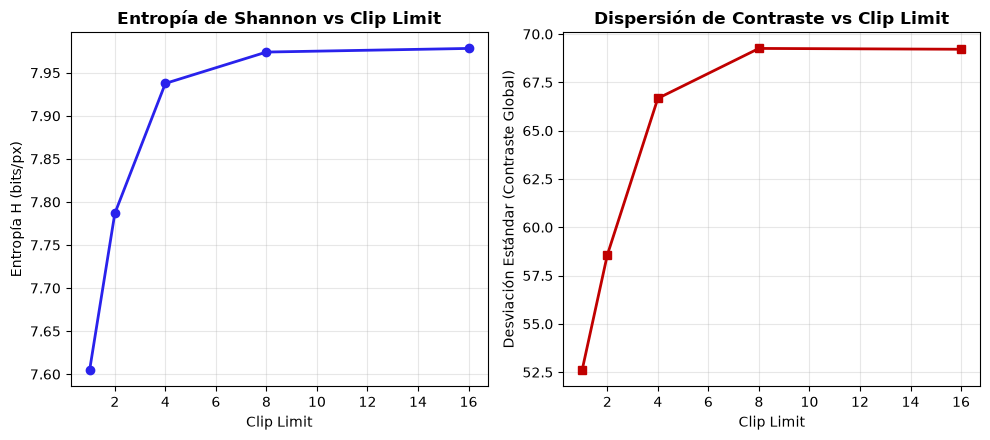

clipLimit=1.0: Entropía=7.6044 bits/px, Desviación estándar=52.5931
clipLimit=2.0: Entropía=7.7867 bits/px, Desviación estándar=58.5687
clipLimit=4.0: Entropía=7.9376 bits/px, Desviación estándar=66.6711
clipLimit=8.0: Entropía=7.9741 bits/px, Desviación estándar=69.2553
clipLimit=16.0: Entropía=7.9783 bits/px, Desviación estándar=69.2128


In [43]:
# 1. Definir rango de hiperparámetros a evaluar
clip_limits = [1.0, 2.0, 4.0, 8.0, 16.0]
entropias = []
contrastes_std = []
resultados_clahe = []

def entropia_shannon(im):
    h, _ = np.histogram(im.ravel(), bins=256, range=[0, 256])
    pk = h / h.sum()
    pk = pk[pk > 0]
    return -np.sum(pk * np.log2(pk))

# ==========================================================================
# TODO: Bucle de evaluación de CLAHE variando clipLimit
# ==========================================================================
for clip in clip_limits:
    clahe_obj = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    out = clahe_obj.apply(img_ihc)
    entropias.append(entropia_shannon(out))
    contrastes_std.append(float(np.std(out)))
    resultados_clahe.append(out)

    # 2. Graficar métricas cuantitativas
plt.figure(figsize=(10, 4.5))
plt.subplot(1, 2, 1)
if len(entropias) > 0:
    plt.plot(clip_limits, entropias, 'o-', color="#2922EC", lw=2)
plt.xlabel('Clip Limit')
plt.ylabel('Entropía H (bits/px)')
plt.title('Entropía de Shannon vs Clip Limit', fontweight='bold')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
if len(contrastes_std) > 0:
    plt.plot(clip_limits, contrastes_std, 's-', color="#C00000", lw=2)
plt.xlabel('Clip Limit')
plt.ylabel('Desviación Estándar (Contraste Global)')
plt.title('Dispersión de Contraste vs Clip Limit', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

for clip, h, s in zip(clip_limits, entropias, contrastes_std):
    print(f"clipLimit={clip}: Entropía={h:.4f} bits/px, Desviación estándar={s:.4f}")

### Conclusión

Al evaluar CLAHE con diferentes valores de clipLimit (1, 2, 4, 8 y 16), se observó que tanto la entropía como la desviación estándar aumentan conforme se incrementa este parámetro. Esto indica una mayor distribución de los niveles de intensidad y un aumento del contraste de la imagen. Sin embargo, el incremento de las métricas se vuelve cada vez menor para valores altos de clipLimit, especialmente al comparar 8 y 16, lo que evidencia un comportamiento de rendimientos decrecientes.

Por eso no conviene usar la ecualización global (HE) en este tipo de imágenes, ya que HE le
cambia el contraste a toda la imagen por igual, pero en una imagen histológica hay partes
muy distintas entre sí, como el tejido y el fondo, así que lo que le sirve a una
parte puede arruinar otra. 
CLAHE resulta mejor porque, en vez de tratar toda la imagen
igual, la divide en pedacitos y mejora cada uno según lo que tiene. El punto que se
considera de compromiso para esta imagen es clipLimit=4, ya que ahí se logra casi todo el contraste
posible (el σ sube de 52.5 a 66.7) sin llegar todavía a la parte donde ya no se gana nada
más y solo se arriesga a meter ruido de más.
Aunque clipLimit=8 tiene los valores más altos de entropía (7.975) y desviación estándar
(69.2), no se eligió como el punto óptimo porque la mejora que aporta respecto a
clipLimit=4 es muy pequeña comparada con la mejora anterior. Esto quiere decir que la
mayor parte del beneficio ya se logra en clipLimit=4, y seguir subiendo hasta 8 agrega
poco a cambio de acercarse más a la zona donde CLAHE empieza a perder el control sobre
el ruido. 


Al evaluar CLAHE con diferentes valores de clipLimit (1, 2, 4, 8 y 16), se observó que tanto la entropía como la desviación estándar aumentan conforme se incrementa este parámetro. Esto indica una mayor distribución de los niveles de intensidad y un aumento del contraste de la imagen. Sin embargo, el incremento de las métricas se vuelve cada vez menor para valores altos de clipLimit, especialmente al comparar 8 y 16, lo que muestra un comportamiento de rendimientos decrecientes.

Por eso, la ecualización global (HE) puede no ser la mejor opción en este tipo de imágenes, ya que cambia el contraste de toda la imagen por igual. En una imagen histológica hay partes muy distintas entre sí, como el tejido y el fondo, así que lo que beneficia a una zona puede afectar negativamente a otra.

CLAHE resulta más conveniente porque en vez de tratar toda la imagen por igual, la divide en regiones y mejora el contraste de cada una de manera local. El punto que se considera de mayor beneficio para esta imagen es clipLimit=4, ya que ahí se logra una mejora importante del contraste (σ aumenta de 52.5 a 66.7), sin llegar todavía a valores demasiado altos que puedan aumentar el riesgo de aumentar el ruido.

Aunque clipLimit=8 tiene valores más altos de entropía (7.975) y desviación estándar (69.2), no se eligió como el mejor punto de compromiso porque la mejora que aporta respecto a clipLimit=4 es pequeña comparada con la mejora anterior. Esto quiere decir que gran parte del beneficio ya se logra con clipLimit=4, y seguir aumentando el valor aporta cada vez menos mejora a cambio de un mayor riesgo de amplificar el ruido.